In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from scipy import stats
import requests
%matplotlib inline

In [2]:
def download(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open (filename, 'w', encoding='utf-8') as f:
            f.write(response.text)
    else:
        print('Download failed: ', response.status_code)

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"
filename = 'EDA_laptops.csv'

download(url, filename)

df = pd.read_csv(filename, index_col=0)

# The first column is a duplicate of index column. So remove it before doing any further analyzing
df.drop(df.columns[0], axis=1, inplace=True)

df.head()

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


### 🧩 Task 1 - Visualize Individual Feature Patterns  

#### Continuous Valued Features  

In this task, we explore how continuous variables relate to **Price**.  
We focus on the following features:  
- `CPU_frequency`  
- `Screen_Size_inch`  
- `Weight_pounds`  

For each feature, we:  
1. **Generate a regression plot** to visualize the linear relationship between the variable and `Price`.  
2. **Compute and print the Pearson correlation coefficient** to measure the strength and direction of the relationship.  



Correlation between CPU_frequency and Price:
               CPU_frequency     Price
CPU_frequency       1.000000  0.366666
Price               0.366666  1.000000


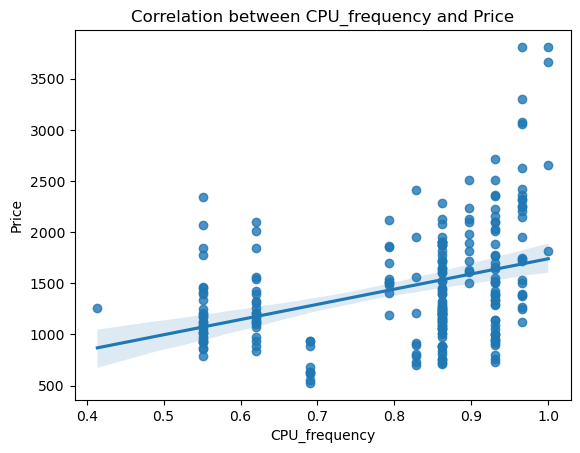


Correlation between Screen_Size_inch and Price:
                  Screen_Size_inch     Price
Screen_Size_inch          1.000000 -0.110644
Price                    -0.110644  1.000000


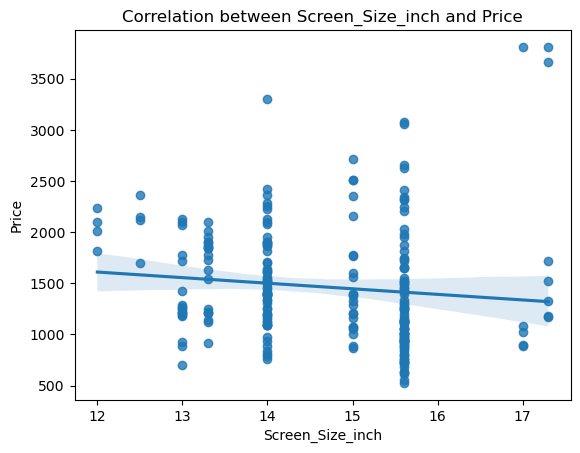


Correlation between Weight_pounds and Price:
               Weight_pounds     Price
Weight_pounds       1.000000 -0.050312
Price              -0.050312  1.000000


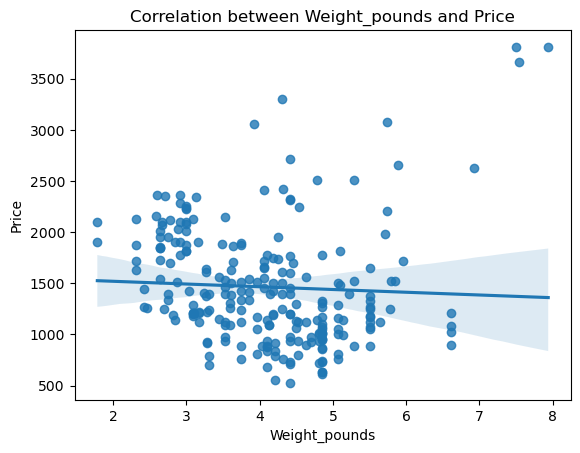



=> Only CPU_frequency shows a moderate correlation with price.
=> The other 2 attributes only show a weak relationship with price.


In [7]:
features = ['CPU_frequency', 'Screen_Size_inch', 'Weight_pounds']

for col in features:
    print(f"\nCorrelation between {col} and Price:")
    print(df[[col, 'Price']].corr())

    sns.regplot(x=col, y='Price', data=df)
    plt.title(f'Correlation between {col} and Price')
    plt.show()

print("\n\n=> Only CPU_frequency shows a moderate correlation with price.")
print("=> The other 2 attributes only show a weak relationship with price.")

### 🎨 Task 2 - Categorical Features  

#### Visualizing Relationships Between Categorical Features and Price  

In this task, we explore how categorical variables affect **Price**.  
The categorical features include:  
- `Category`  
- `GPU`  
- `OS`  
- `CPU_core`  
- `RAM_GB`  
- `Storage_GB_SSD`  

We use **Box Plots** to visualize how laptop prices vary across each category.  
Each box represents the **distribution of prices** within one group of a categorical feature — showing the median, quartiles, and potential outliers.  

**Interpretation Guide:**  
- A **wide range** or **higher median** in a group indicates higher price variation or generally more expensive models.  
- **Non-overlapping boxes** between categories suggest strong influence of that feature on price.  

In [6]:
colors = ['skyblue', 'lightgreen', 'orange', 'violet', 'gold', 'salmon']

for i, col in enumerate(['Category', 'GPU', 'OS', 'CPU_core', 'RAM_GB', 'Storage_GB_SSD']):
    fig = px.box(df, x=col, y='Price',
                 title=f'Price variance across {col}',
                 color_discrete_sequence=[colors[i % len(colors)]])
    fig.show()


### 📈 Task 2 - Descriptive Statistical Analysis  

Generate a **statistical summary** for all features in the dataset, including both **numerical** and **categorical (object)** data types.  
This provides insights into data distribution, central tendency, and spread.  

In [10]:
print(df.describe())
print(df.describe(include=object))

         Category         GPU          OS    CPU_core  Screen_Size_inch  \
count  238.000000  238.000000  238.000000  238.000000        238.000000   
mean     3.205882    2.151261    1.058824    5.630252         14.688655   
std      0.776533    0.638282    0.235790    1.241787          1.166045   
min      1.000000    1.000000    1.000000    3.000000         12.000000   
25%      3.000000    2.000000    1.000000    5.000000         14.000000   
50%      3.000000    2.000000    1.000000    5.000000         15.000000   
75%      4.000000    3.000000    1.000000    7.000000         15.600000   
max      5.000000    3.000000    2.000000    7.000000         17.300000   

       CPU_frequency      RAM_GB  Storage_GB_SSD  Weight_pounds        Price  \
count     238.000000  238.000000      238.000000     238.000000   238.000000   
mean        0.813822    7.882353      245.781513       4.106221  1462.344538   
std         0.141860    2.482603       34.765316       1.078442   574.607699   
min 

### 🧮 Task 3 - GroupBy and Pivot Tables  

In this task, we analyze how **GPU** and **CPU_core** together influence **Price**.  

**Steps:**  
1. Use `groupby()` to group data by `GPU` and `CPU_core`, calculating the **mean price** for each combination.  
2. Convert the grouped result into a **pivot table** using `pivot(index='GPU', columns='CPU_core')` for easier visualization.  
3. Display the relationship using a **pcolor (heatmap)** plot, where color intensity represents the average price.  

**Interpretation:**  
- Darker or lighter color regions indicate different average price levels.  
- Clear color gradients suggest that GPU type and CPU core count strongly affect laptop prices.  

   GPU  CPU_core        Price
0    1         3   769.250000
1    1         5   998.500000
2    1         7  1167.941176
3    2         3   785.076923
4    2         5  1462.197674
5    2         7  1744.621622
6    3         3   784.000000
7    3         5  1220.680000
8    3         7  1945.097561
               Price                          
CPU_core           3            5            7
GPU                                           
1         769.250000   998.500000  1167.941176
2         785.076923  1462.197674  1744.621622
3         784.000000  1220.680000  1945.097561


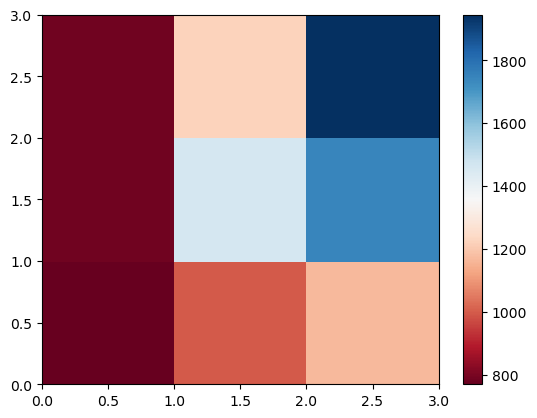

In [15]:
df_gptest = df[['GPU','CPU_core','Price']]
grouped_test1 = df_gptest.groupby(['GPU','CPU_core'],as_index=False).mean()
print(grouped_test1)

grouped_pivot = grouped_test1.pivot(index='GPU',columns='CPU_core')
print(grouped_pivot)

fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot, cmap='RdBu')
fig.colorbar(im)
plt.show()

### 🔬 Task 4 - Pearson Correlation and p-values  

In this task, we evaluate how strongly each numerical feature is related to **Price** using the **Pearson correlation coefficient** and its corresponding **p-value** from `scipy.stats.pearsonr()`.  

**Steps:**  
1. For each continuous feature tested earlier (e.g., `CPU_frequency`, `Screen_Size_inch`, `Weight_pounds`), calculate:  
   - **Pearson r** → measures the strength and direction of linear correlation.  
   - **p-value** → indicates statistical significance of that relationship.  
2. Interpret the results to identify which features have the **strongest influence** on laptop prices.  

**Interpretation Guide:**  
- |r| close to **1** → strong correlation  
- |r| close to **0** → weak correlation  
- **p-value < 0.05** → statistically significant relationship  

In [24]:
for param in ['RAM_GB','CPU_frequency','Storage_GB_SSD','Screen_Size_inch','Weight_pounds','CPU_core','OS','GPU','Category']:
    pearson_coef, p_value = stats.pearsonr(df[param], df['Price'])
    print(f"\nRelationship between {param} and Price")
    print(f"The Pearson Correlation Coefficient for {param} is {pearson_coef:.2f} with a P-value of P = {p_value:.2e}")


Relationship between RAM_GB and Price
The Pearson Correlation Coefficient for RAM_GB is 0.55 with a P-value of P = 3.68e-20

Relationship between CPU_frequency and Price
The Pearson Correlation Coefficient for CPU_frequency is 0.37 with a P-value of P = 5.50e-09

Relationship between Storage_GB_SSD and Price
The Pearson Correlation Coefficient for Storage_GB_SSD is 0.24 with a P-value of P = 1.49e-04

Relationship between Screen_Size_inch and Price
The Pearson Correlation Coefficient for Screen_Size_inch is -0.11 with a P-value of P = 8.85e-02

Relationship between Weight_pounds and Price
The Pearson Correlation Coefficient for Weight_pounds is -0.05 with a P-value of P = 4.40e-01

Relationship between CPU_core and Price
The Pearson Correlation Coefficient for CPU_core is 0.46 with a P-value of P = 7.91e-14

Relationship between OS and Price
The Pearson Correlation Coefficient for OS is -0.22 with a P-value of P = 5.70e-04

Relationship between GPU and Price
The Pearson Correlation Co